# Data Preparation & Initialization

### Set Gobal Seed

In [1]:
Seed = 1

### Import Data

In [2]:
import pandas as pd

df = pd.read_csv("packet-data/for_data.csv")

df.head()

,channel_10_count,channel_10_mean,channel_10_var,channel_1_count,channel_1_mean,channel_1_var,channel_30_count,channel_30_mean,channel_30_var,channel_5_count,...,stream_unique_dst_ips_seen_so_far,stream_unique_dst_ports_seen_so_far,sum_p,tcp_window_size,time_since_previously_displayed_frame,ttl,uri_special_chars,var_p,id,label
0,-1.581537,-0.842522,0.771697,-1.311927,-0.811524,-1.431741,-1.826406,-0.842090,0.786877,-1.494342,...,-1.827695,-1.673529,-0.779439,-1.432806,0.011012,-0.530232,-0.057043,-0.803359,0,benign
1,-0.263427,-0.762558,-0.361727,-0.341756,-0.750308,-0.064285,0.143060,-0.774783,-0.462200,-0.454379,...,-1.827695,-1.673529,-0.558099,0.907656,0.002189,-0.579482,-0.057043,-0.639181,1,benign
2,-0.807535,-0.435740,0.300755,-0.720894,-0.442117,0.570058,-0.589184,-0.439128,0.273772,-0.663654,...,-1.827695,-1.673529,-0.900192,0.290262,-0.011846,-0.530232,-0.057043,-0.670437,2,benign
3,-0.191515,-0.885359,-1.022789,-1.050391,-0.784083,-0.054231,-0.034582,-0.866827,-0.443953,-0.233760,...,-1.827695,-1.673529,-0.379196,-1.432806,-0.011856,-1.318230,-0.057043,-0.042758,4,benign
4,0.192499,-0.834817,-1.149986,-0.417729,-0.797050,-0.481221,0.047961,-0.832411,-1.139740,0.051862,...,-1.326492,-1.673529,-0.880612,-1.432806,0.030819,-0.530232,-0.057043,-1.253344,5,benign


### Drop Variables Not Used
- Drop "id" column

In [3]:
# Preserve IDs for linking Phase 2 alerts to Phase 3 flow records.
packet_ids = df["id"].copy() if "id" in df.columns else pd.Series(df.index)

# ID is an identifier, not a behavioral feature.
df = df.drop(columns=["id"], errors="ignore")

df.head()

,channel_10_count,channel_10_mean,channel_10_var,channel_1_count,channel_1_mean,channel_1_var,channel_30_count,channel_30_mean,channel_30_var,channel_5_count,...,stream_rate_5,stream_unique_dst_ips_seen_so_far,stream_unique_dst_ports_seen_so_far,sum_p,tcp_window_size,time_since_previously_displayed_frame,ttl,uri_special_chars,var_p,label
0,-1.581537,-0.842522,0.771697,-1.311927,-0.811524,-1.431741,-1.826406,-0.842090,0.786877,-1.494342,...,-1.194937,-1.827695,-1.673529,-0.779439,-1.432806,0.011012,-0.530232,-0.057043,-0.803359,benign
1,-0.263427,-0.762558,-0.361727,-0.341756,-0.750308,-0.064285,0.143060,-0.774783,-0.462200,-0.454379,...,-0.473560,-1.827695,-1.673529,-0.558099,0.907656,0.002189,-0.579482,-0.057043,-0.639181,benign
2,-0.807535,-0.435740,0.300755,-0.720894,-0.442117,0.570058,-0.589184,-0.439128,0.273772,-0.663654,...,-0.941186,-1.827695,-1.673529,-0.900192,0.290262,-0.011846,-0.530232,-0.057043,-0.670437,benign
3,-0.191515,-0.885359,-1.022789,-1.050391,-0.784083,-0.054231,-0.034582,-0.866827,-0.443953,-0.233760,...,-0.091238,-1.827695,-1.673529,-0.379196,-1.432806,-0.011856,-1.318230,-0.057043,-0.042758,benign
4,0.192499,-0.834817,-1.149986,-0.417729,-0.797050,-0.481221,0.047961,-0.832411,-1.139740,0.051862,...,0.131979,-1.326492,-1.673529,-0.880612,-1.432806,0.030819,-0.530232,-0.057043,-1.253344,benign


### Create Data Matrix and Label Vector

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate labels for stratification and evaluation; labels are never passed to fit().
X = df.drop(columns=["label"]).to_numpy()
y = df["label"].to_numpy()

print("Data matrix shape:", X.shape)
print("Label vector shape:", y.shape)

row_indices = np.arange(X.shape[0])
X_train, X_remaining, y_train, y_remaining, index_train, index_remaining = train_test_split(
    X, y, row_indices, test_size=0.4, stratify=y, random_state=Seed
)
X_validation, X_test, y_validation, y_test, index_validation, index_test = train_test_split(
    X_remaining,
    y_remaining,
    index_remaining,
    test_size=0.5,
    stratify=y_remaining,
    random_state=Seed,
)

# Fit preprocessing only on the training partition.
phase2_scaler = StandardScaler()
X_train_scaled = phase2_scaler.fit_transform(X_train)
X_validation_scaled = phase2_scaler.transform(X_validation)
X_test_scaled = phase2_scaler.transform(X_test)

# Phase 2 models learn the normal profile only from benign training rows.
benign_train_mask = y_train == "benign"

print("Train/validation/test sizes:", X_train.shape[0], X_validation.shape[0], X_test.shape[0])
print("Benign-only training rows:", benign_train_mask.sum())
print("Attack rows excluded from model fitting:", (~benign_train_mask).sum())
print("Labels are retained only for analysis and model selection, not passed as features.")

Data matrix shape: (195940, 126)
Label vector shape: (195940,)
Train/validation/test sizes: 117564 39188 39188
Benign-only training rows: 114000
Attack rows excluded from model fitting: 3564
Labels are retained only for analysis and model selection, not passed as features.


# K-means (high-recall alert generator)

### K-means Hyperparameters Tuning
- Hyperparameters:
    - K: number of clusters used to represent benign behaviour
    - Threshold_percentile: distance cutoff for classifying a sample as anomalous

- Model selection uses validation results 
    - recall >= 0.9 and FPR <= 0.15
    - if non qualify
    - keep configuration with FPR <= 0.15


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix,
                             roc_auc_score, average_precision_score)

k_values = [2, 4, 6, 8, 10, 15, 20, 40, 50, 60, 80, 100]
threshold_percentiles = [80, 85, 90, 92, 95, 97, 99]

# Fit K-means only on benign training features; labels are used only to select rows and evaluate.
X_kmeans_train = X_train_scaled[benign_train_mask]
X_evaluation = X_validation_scaled
y_evaluation = y_validation
y_attack = y_validation[y_validation != "benign"]
true_attack = y_evaluation != "benign"

models = {}
thresholds = {}
inertias = []
kmeans_results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=5,
        random_state=Seed,
    )
    model.fit(X_kmeans_train)

    # A sample is anomalous when its nearest-centroid distance exceeds
    # the chosen percentile of benign-only training distances.
    training_distances = model.transform(X_kmeans_train).min(axis=1)
    evaluation_distances = model.transform(X_evaluation).min(axis=1)

    models[k] = model
    inertias.append(model.inertia_)

    for percentile in threshold_percentiles:
        threshold = np.percentile(training_distances, percentile)
        predicted_attack = evaluation_distances > threshold

        precision = precision_score(true_attack, predicted_attack, zero_division=0)
        recall = recall_score(true_attack, predicted_attack, zero_division=0)
        f1 = f1_score(true_attack, predicted_attack, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(
            true_attack, predicted_attack, labels=[False, True]
        ).ravel()
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        fnr = fn / (fn + tp) if (fn + tp) else 0.0

        thresholds[(k, percentile)] = threshold
        kmeans_results.append({
            "k": k,
            "threshold_percentile": percentile,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "fpr": fpr,
            "fnr": fnr,
        })

        print(
            f"k={k}, percentile={percentile}: Precision={precision:.4f}, "
            f"Recall={recall:.4f}, F1={f1:.4f}"
        )
        print("  Confusion matrix [[TP, FP], [FN, TN]]:")
        print("  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]")
        print(np.array([[tp, fp], [fn, tn]]))
        for attack in sorted(np.unique(y_attack)):
            attack_mask = y_evaluation == attack
            detection_rate = predicted_attack[attack_mask].mean()
            print(f"  {attack} detection rate: {detection_rate:.4f}")

kmeans_results_df = pd.DataFrame(kmeans_results)
display(
    kmeans_results_df.sort_values("fnr", ascending=True).reset_index(drop=True)
)

# Prefer high recall for Phase 2, while limiting validation false alarms.
eligible_kmeans = kmeans_results_df[
    (kmeans_results_df["recall"] >= 0.90) & (kmeans_results_df["fpr"] <= 0.15)
]
if eligible_kmeans.empty:
    eligible_kmeans = kmeans_results_df[kmeans_results_df["fpr"] <= 0.15]
if eligible_kmeans.empty:
    eligible_kmeans = kmeans_results_df
best_kmeans_config = eligible_kmeans.sort_values(
    ["fnr", "fpr", "f1"], ascending=[True, True, False]
).iloc[0]

best_k = int(best_kmeans_config["k"])
best_kmeans_percentile = int(best_kmeans_config["threshold_percentile"])
best_kmeans_model = models[best_k]
best_kmeans_threshold = thresholds[(best_k, best_kmeans_percentile)]
kmeans_test_scores = best_kmeans_model.transform(X_test_scaled).min(axis=1)
kmeans_test_predictions = kmeans_test_scores > best_kmeans_threshold
kmeans_test_truth = y_test != "benign"
kmeans_test_precision = precision_score(kmeans_test_truth, kmeans_test_predictions, zero_division=0)
kmeans_test_recall = recall_score(kmeans_test_truth, kmeans_test_predictions, zero_division=0)
kmeans_test_f1 = f1_score(kmeans_test_truth, kmeans_test_predictions, zero_division=0)
kmeans_tn, kmeans_fp, kmeans_fn, kmeans_tp = confusion_matrix(
    kmeans_test_truth, kmeans_test_predictions, labels=[False, True]
).ravel()
kmeans_test_fpr = kmeans_fp / (kmeans_fp + kmeans_tn)
kmeans_test_fnr = kmeans_fn / (kmeans_fn + kmeans_tp)
kmeans_test_roc_auc = roc_auc_score(kmeans_test_truth, kmeans_test_scores)
kmeans_test_pr_auc = average_precision_score(kmeans_test_truth, kmeans_test_scores)
print(
    f"Final K-means test: k={best_k}, percentile={best_kmeans_percentile}, "
    f"Precision={kmeans_test_precision:.4f}, Recall={kmeans_test_recall:.4f}, "
    f"F1={kmeans_test_f1:.4f}, FPR={kmeans_test_fpr:.4f}, "
    f"FNR={kmeans_test_fnr:.4f}, ROC-AUC={kmeans_test_roc_auc:.4f}, "
    f"PR-AUC={kmeans_test_pr_auc:.4f}"
)
print(np.array([[kmeans_tp, kmeans_fp], [kmeans_fn, kmeans_tn]]))
for attack in sorted(np.unique(y_test[y_test != "benign"])):
    attack_mask = y_test == attack
    print(f"  {attack} detection rate: {kmeans_test_predictions[attack_mask].mean():.4f}")

kmeans_alerts_df = pd.DataFrame({
    "packet_id": packet_ids.iloc[index_test].to_numpy(),
    "true_label": y_test,
    "anomaly_score": kmeans_test_scores,
    "alert": kmeans_test_predictions,
})
kmeans_alerts_df = kmeans_alerts_df[kmeans_alerts_df["alert"]].reset_index(drop=True)

k=2, percentile=80: Precision=0.1083, Recall=0.7626, F1=0.1896
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  906  7463]
 [  282 30537]]
  brute_force detection rate: 0.7848
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.5294
  dos detection rate: 0.9832
  xss detection rate: 0.5168
k=2, percentile=85: Precision=0.1287, Recall=0.7079, F1=0.2177
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  841  5696]
 [  347 32304]]
  brute_force detection rate: 0.7089
  ddos detection rate: 0.9831
  dns_spoofing detection rate: 0.4328
  dos detection rate: 0.9496
  xss detection rate: 0.4664
k=2, percentile=90: Precision=0.1622, Recall=0.6162, F1=0.2568
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  732  3780]
 [  456 34220]]
  brute_force detection rate: 0.5738
  ddos detection rate: 0.

,k,threshold_percentile,precision,recall,f1,fpr,fnr
0,100,80,0.128406,0.963805,0.226620,0.204526,0.036195
1,80,80,0.129241,0.958754,0.227777,0.201947,0.041246
2,60,80,0.126970,0.949495,0.223987,0.204105,0.050505
3,100,85,0.162513,0.949495,0.277525,0.152974,0.050505
4,40,80,0.127604,0.948653,0.224950,0.202763,0.051347
...,...,...,...,...,...,...,...
79,2,97,0.235652,0.293771,0.261521,0.029789,0.706229
80,8,99,0.442060,0.260101,0.327504,0.010263,0.739899
81,2,99,0.151927,0.056397,0.082259,0.009842,0.943603
82,6,99,0.137472,0.052189,0.075656,0.010237,0.947811


Final K-means test: k=80, percentile=85, Precision=0.1664, Recall=0.9428, F1=0.2829, FPR=0.1476, FNR=0.0572, ROC-AUC=0.9661, PR-AUC=0.6762
[[ 1120  5609]
 [   68 32391]]
  brute_force detection rate: 0.9832
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.7468
  dos detection rate: 1.0000
  xss detection rate: 0.9831


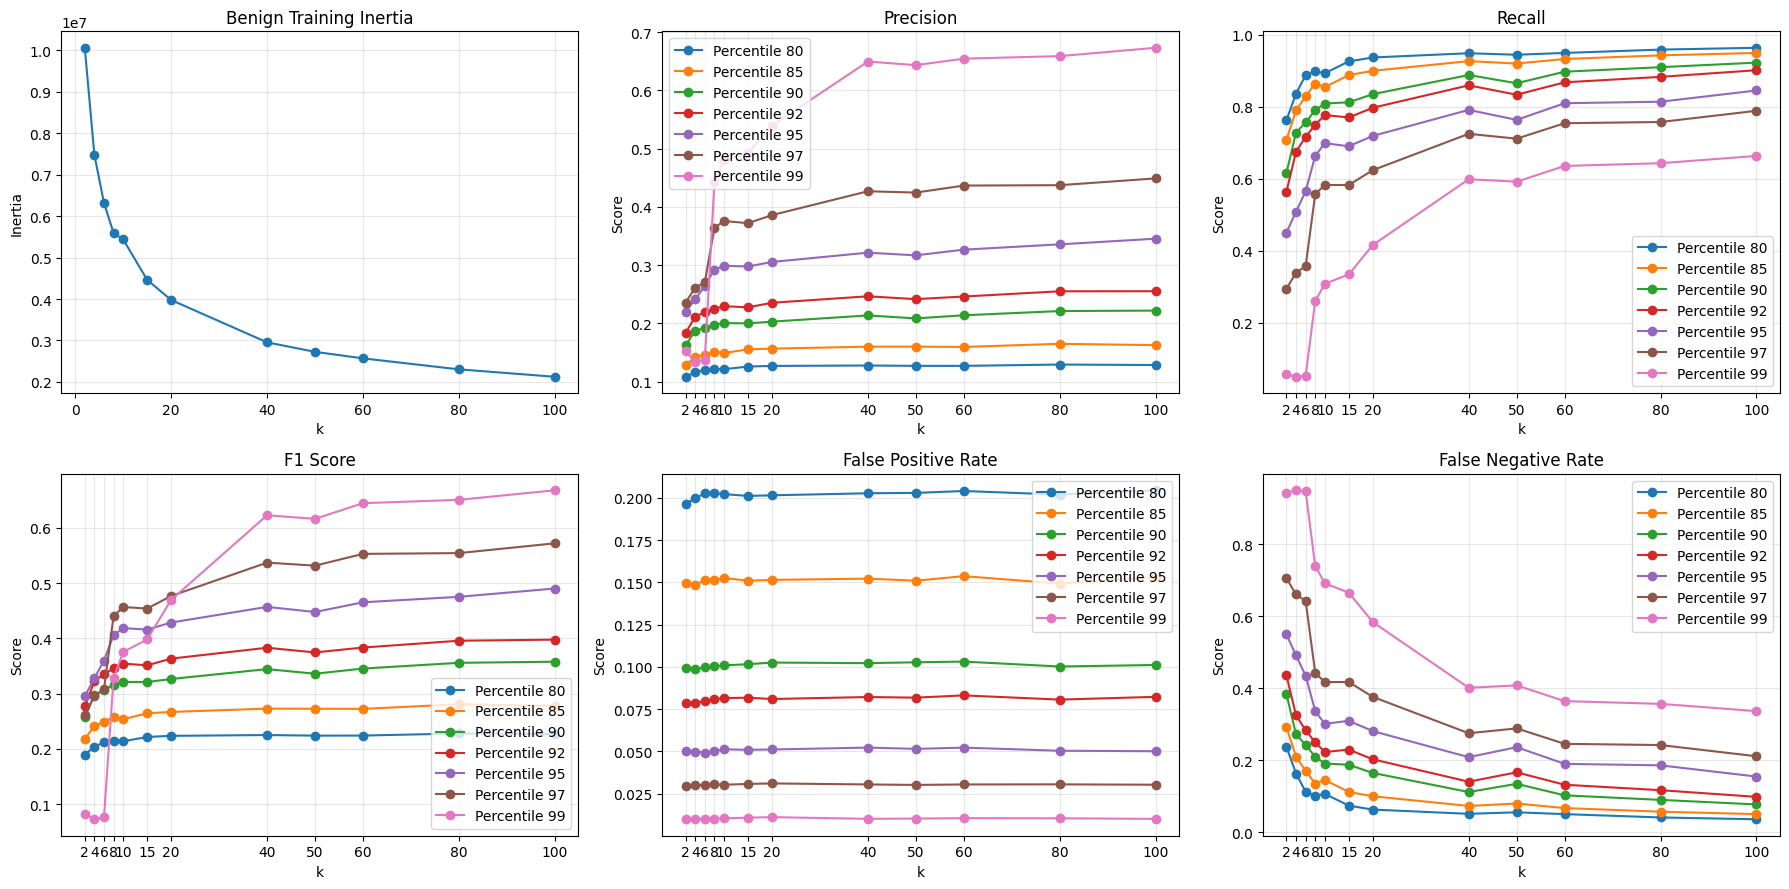

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

# Plot inertia to show how well the model fits the benign training data.
axes[0].plot(k_values, inertias, marker="o")
axes[0].set(title="Benign Training Inertia", xlabel="k", ylabel="Inertia")
axes[0].grid(alpha=0.3)

# Plot each metric for every threshold percentile.
for axis, metric, title in zip(
    axes[1:],
    ["precision", "recall", "f1", "fpr", "fnr"],
    ["Precision", "Recall", "F1 Score", "False Positive Rate", "False Negative Rate"],
):
    for percentile in threshold_percentiles:
        subset = kmeans_results_df[
            kmeans_results_df["threshold_percentile"] == percentile
        ].sort_values("k")
        axis.plot(
            subset["k"], subset[metric], marker="o", label=f"Percentile {percentile}"
        )
    axis.set(title=title, xlabel="k", ylabel="Score")
    axis.set_xticks(k_values)
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

# Autoencoders (high-recall alert generator)

### Autoencoders Hyperparameters Tuning
- Hyperparameters:
    - bottleneck_size: number of neurons after encoding
    - Threshold_percentile: distance cutoff for classifying a sample as anomalous

- Model selection uses validation results 
    - recall >= 0.9 and FPR <= 0.15
    - if non qualify
    - keep configuration with FPR <= 0.15

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix,
                             roc_auc_score, average_precision_score)

keras.utils.set_random_seed(Seed)

bottleneck_sizes = [2, 4, 8, 16, 32]
threshold_percentiles = [80, 85, 90, 92, 95, 97, 99]

# Fit the autoencoder only on benign training features.
X_benign_train_ae = X_train_scaled[benign_train_mask].astype(np.float32)
X_evaluation_ae = X_validation_scaled.astype(np.float32)
y_evaluation_ae = y_validation
y_attack_ae = y_validation[y_validation != "benign"]
true_attack_ae = y_evaluation_ae != "benign"

input_dim = X_benign_train_ae.shape[1]
autoencoder_models = {}
ae_results = []

for bottleneck_size in bottleneck_sizes:
    keras.backend.clear_session()
    keras.utils.set_random_seed(Seed)

    inputs = keras.Input(shape=(input_dim,))
    encoded = keras.layers.Dense(64, activation="relu")(inputs)
    bottleneck = keras.layers.Dense(
        bottleneck_size, activation="relu", name="bottleneck"
    )(encoded)
    decoded = keras.layers.Dense(64, activation="relu")(bottleneck)
    outputs = keras.layers.Dense(input_dim)(decoded)
    autoencoder = keras.Model(inputs, outputs, name=f"autoencoder_{bottleneck_size}")
    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
    history = autoencoder.fit(
        X_benign_train_ae,
        X_benign_train_ae,
        epochs=50,
        batch_size=512,
        validation_split=0.1,
        shuffle=True,
        callbacks=[early_stopping],
        verbose=0,
    )
    autoencoder_models[bottleneck_size] = autoencoder
    print(f"Bottleneck {bottleneck_size}: trained for {len(history.history['loss'])} epochs")

    train_reconstruction = autoencoder.predict(X_benign_train_ae, verbose=0)
    train_errors = np.mean(
        (X_benign_train_ae - train_reconstruction) ** 2, axis=1
    )
    evaluation_reconstruction = autoencoder.predict(X_evaluation_ae, verbose=0)
    evaluation_errors = np.mean(
        (X_evaluation_ae - evaluation_reconstruction) ** 2, axis=1
    )

    for percentile in threshold_percentiles:
        threshold = np.percentile(train_errors, percentile)
        predicted_attack = evaluation_errors > threshold

        precision = precision_score(
            true_attack_ae, predicted_attack, zero_division=0
        )
        f1 = f1_score(true_attack_ae, predicted_attack, zero_division=0)
        recall = recall_score(true_attack_ae, predicted_attack, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(
            true_attack_ae, predicted_attack, labels=[False, True]
        ).ravel()
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        fnr = fn / (fn + tp) if (fn + tp) else 0.0

        result = {
            "bottleneck_size": bottleneck_size,
            "threshold_percentile": percentile,
            "threshold": threshold,
            "precision": precision,
            "f1": f1,
            "recall": recall,
            "fpr": fpr,
            "fnr": fnr,
        }
        ae_results.append(result)

        print(
            f"bottleneck={bottleneck_size}, percentile={percentile}: "
            f"Precision={precision:.4f}, Recall={recall:.4f}, "
            f"F1={f1:.4f}"
        )
        print("  Confusion matrix [[TP, FP], [FN, TN]]:")
        print("  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]")
        print(np.array([[tp, fp], [fn, tn]]))
        for attack in sorted(np.unique(y_attack_ae)):
            attack_mask = y_evaluation_ae == attack
            detection_rate = predicted_attack[attack_mask].mean()
            print(f"  {attack} detection rate: {detection_rate:.4f}")

ae_results_df = pd.DataFrame(ae_results)
display(
    ae_results_df.sort_values("fnr", ascending=True).reset_index(drop=True)
)

# Select on validation data: prioritize recall, then control false alarms.
eligible_ae = ae_results_df[
    (ae_results_df["recall"] >= 0.90) & (ae_results_df["fpr"] <= 0.15)
]
if eligible_ae.empty:
    eligible_ae = ae_results_df[ae_results_df["fpr"] <= 0.15]
if eligible_ae.empty:
    eligible_ae = ae_results_df
best_ae_config = eligible_ae.sort_values(
    ["fnr", "fpr", "f1"], ascending=[True, True, False]
).iloc[0]
best_bottleneck_size = int(best_ae_config["bottleneck_size"])
best_ae_percentile = int(best_ae_config["threshold_percentile"])
best_autoencoder = autoencoder_models[best_bottleneck_size]
best_ae_threshold = float(best_ae_config["threshold"])

X_test_ae = X_test_scaled.astype(np.float32)
ae_test_reconstruction = best_autoencoder.predict(X_test_ae, verbose=0)
ae_test_scores = np.mean((X_test_ae - ae_test_reconstruction) ** 2, axis=1)
ae_test_predictions = ae_test_scores > best_ae_threshold
ae_test_truth = y_test != "benign"
ae_test_precision = precision_score(ae_test_truth, ae_test_predictions, zero_division=0)
ae_test_recall = recall_score(ae_test_truth, ae_test_predictions, zero_division=0)
ae_test_f1 = f1_score(ae_test_truth, ae_test_predictions, zero_division=0)
ae_tn, ae_fp, ae_fn, ae_tp = confusion_matrix(
    ae_test_truth, ae_test_predictions, labels=[False, True]
).ravel()
ae_test_fpr = ae_fp / (ae_fp + ae_tn)
ae_test_fnr = ae_fn / (ae_fn + ae_tp)
ae_test_roc_auc = roc_auc_score(ae_test_truth, ae_test_scores)
ae_test_pr_auc = average_precision_score(ae_test_truth, ae_test_scores)
print(
    f"Final autoencoder test: bottleneck={best_bottleneck_size}, "
    f"percentile={best_ae_percentile}, Precision={ae_test_precision:.4f}, "
    f"Recall={ae_test_recall:.4f}, F1={ae_test_f1:.4f}, "
    f"FPR={ae_test_fpr:.4f}, FNR={ae_test_fnr:.4f}, "
    f"ROC-AUC={ae_test_roc_auc:.4f}, PR-AUC={ae_test_pr_auc:.4f}"
)
print(np.array([[ae_tp, ae_fp], [ae_fn, ae_tn]]))
for attack in sorted(np.unique(y_test[y_test != "benign"])):
    attack_mask = y_test == attack
    print(f"  {attack} detection rate: {ae_test_predictions[attack_mask].mean():.4f}")

autoencoder_alerts_df = pd.DataFrame({
    "packet_id": packet_ids.iloc[index_test].to_numpy(),
    "true_label": y_test,
    "anomaly_score": ae_test_scores,
    "alert": ae_test_predictions,
})
autoencoder_alerts_df = autoencoder_alerts_df[
    autoencoder_alerts_df["alert"]
].reset_index(drop=True)

Bottleneck 2: trained for 50 epochs
bottleneck=2, percentile=80: Precision=0.1253, Recall=0.9268, F1=0.2208
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1101  7684]
 [   87 30316]]
  brute_force detection rate: 0.9662
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.6933
  dos detection rate: 1.0000
  xss detection rate: 0.9748
bottleneck=2, percentile=85: Precision=0.1538, Recall=0.8889, F1=0.2622
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1056  5810]
 [  132 32190]]
  brute_force detection rate: 0.9494
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.5672
  dos detection rate: 1.0000
  xss detection rate: 0.9286
bottleneck=2, percentile=90: Precision=0.1998, Recall=0.8165, F1=0.3211
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  970  3884]
 [  218 34116]]

,bottleneck_size,threshold_percentile,threshold,precision,f1,recall,fpr,fnr
0,32,80,0.037437,0.131864,0.232797,0.992424,0.204263,0.007576
1,16,80,0.077241,0.130179,0.230007,0.986532,0.206079,0.013468
2,32,85,0.042600,0.166548,0.284772,0.981481,0.153553,0.018519
3,16,85,0.088062,0.164966,0.282387,0.979798,0.155053,0.020202
4,8,80,0.149682,0.128993,0.227766,0.972222,0.205237,0.027778
5,32,90,0.050695,0.226959,0.367706,0.968013,0.103079,0.031987
6,16,90,0.103509,0.225167,0.365170,0.965488,0.103868,0.034512
7,32,92,0.055442,0.267072,0.418009,0.961279,0.082474,0.038721
8,8,85,0.168875,0.161003,0.275636,0.957071,0.155921,0.042929
9,4,80,0.218217,0.126616,0.223622,0.956229,0.206211,0.043771


Final autoencoder test: bottleneck=32, percentile=90, Precision=0.2350, Recall=0.9722, F1=0.3785, FPR=0.0989, FNR=0.0278, ROC-AUC=0.9850, PR-AUC=0.7891
[[ 1155  3760]
 [   33 34240]]
  brute_force detection rate: 1.0000
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.8650
  dos detection rate: 1.0000
  xss detection rate: 0.9958


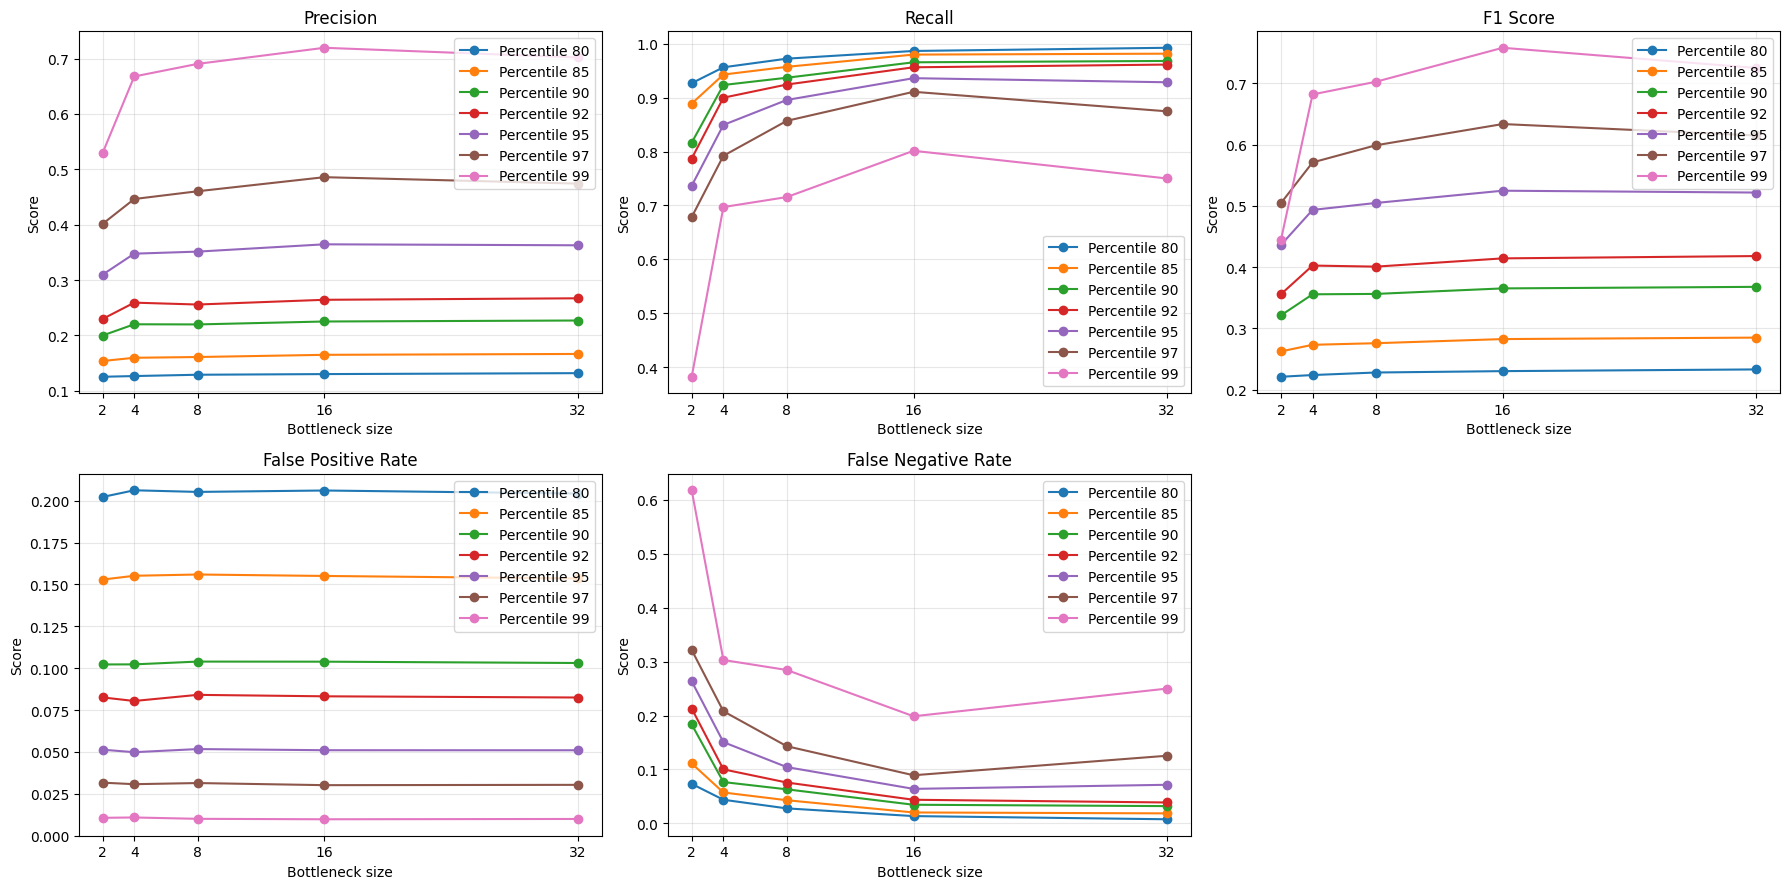

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for axis, metric, title in zip(
    axes[:5],
    ["precision", "recall", "f1", "fpr", "fnr"],
    ["Precision", "Recall", "F1 Score", "False Positive Rate", "False Negative Rate"],
):
    for percentile in threshold_percentiles:
        subset = ae_results_df[
            ae_results_df["threshold_percentile"] == percentile
        ].sort_values("bottleneck_size")
        axis.plot(
            subset["bottleneck_size"],
            subset[metric],
            marker="o",
            label=f"Percentile {percentile}",
        )
    axis.set(title=title, xlabel="Bottleneck size", ylabel="Score")
    axis.set_xticks(bottleneck_sizes)
    axis.grid(alpha=0.3)
    axis.legend()

axes[5].axis("off")
plt.tight_layout()
plt.show()

### Final Phase 2 Test Curves

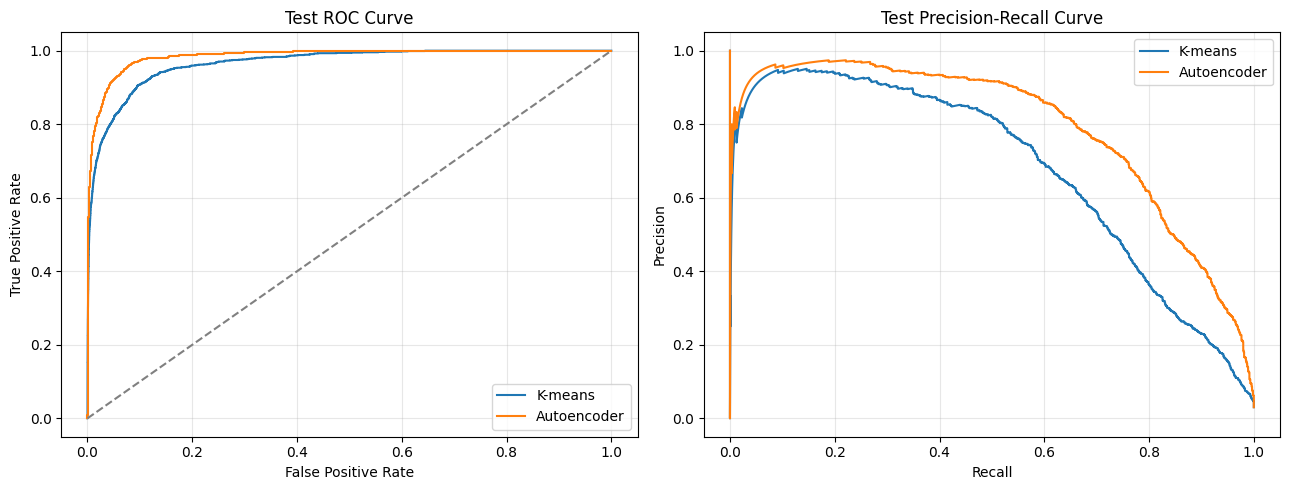

In [9]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, scores in [
    ("K-means", kmeans_test_scores),
    ("Autoencoder", ae_test_scores),
]:
    fpr_curve, tpr_curve, _ = roc_curve(ae_test_truth, scores)
    curve_precision, curve_recall, _ = precision_recall_curve(ae_test_truth, scores)
    axes[0].plot(fpr_curve, tpr_curve, label=name)
    axes[1].plot(curve_recall, curve_precision, label=name)

axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set(title="Test ROC Curve", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[1].set(title="Test Precision-Recall Curve", xlabel="Recall", ylabel="Precision")
for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()